# TS2: "Modelizando un ADC"
## Alumno: Suarez Lucila

En esta tarea semanal se realizo una simulacion del bloque de cuantizacion de un ADC de B bits en un rango de +/- VF (en este trabajo se llamara Vref) Volts. 
Para ello, se simulo el comportamiento del dispositivo digital de una senoidal contaminada con un nivel predeteminado de ruido.

Comenzamos definiendo los parametros para el desarrollo del codigo:
Siendo fs: Frecuencia de muestreo (Hz); nn: Numero de muestras; $\Delta f$: Resolucion espectral(fs/nn); ff: Frecuencia de la senoidal; B: Resolucion del ADC en bits; Vref: Rango analogico(db); qq: Paso de cuantizacion; Pq: Potencia teorica del ruido de cuantizacion; Pn: Potencia del ruido analogico. 

In [34]:
import numpy as np 
import matplotlib.pyplot as plt

fs = 1000       # Frecuencia de muestreo (Hz)
nn = 1000       # Número de muestras
dc=0
ph=0
ur=0            #media del ruido
df=fs/nn        #resol espectral
ff=df            # k*fs/nn
bins=np.arange(0, nn // 2) * df # hasta nyquist
vmax=np.sqrt(2)

#%%ADC 
B=4 #bits
Vref=2#(db) rango analogico, nos aseguramos que tiene 3,3 de rango con 1.65
qq=2*Vref/(2**B)
k=1

Pq=(qq**2)/12 #potencia del ruido de cuantizacion 
Psen=(vmax**2)/2
Pn=k*Pq #pot analogica
SNR=10*np.log10(Psen/Pn)

Comenzamos generando la senoidal y el ruido gaussiano por separado.Para formar la señal que entra al ADC, sumamos dichas componentes (xx_ruidosa = xx + ruido). Luego, calculamos el ruido de cuantizacion nq=xx_q-xx_ruidosa, con la resta de xx_q como el redondeo de la salida cuantizada del ADC y xx_ruidosa como la señal que entro al bloque de cuantizacion. 

In [35]:
#%%#%%2. GENERACIÓN DE SEÑAL Y RUIDO
tt = np.arange(nn) / fs
xx = np.sin(2 * np.pi * ff * tt) # Senoidal pura

# Generar ruido gaussiano
#Pruido = 10 ** (-SNR / 10 + np.log10(Ps))
dv = np.sqrt(Pn) #calculo del desvio estandar del ruido analogico gaussiano
ruido = np.random.normal(ur, dv, nn)#muestras del ruido analogico

# Sumar en el DOMINIO DEL TIEMPO (correcto)
xx_ruidosa = xx + ruido #señal mas ruido analogico

#%%Cuantizacion

xx_q=np.round(xx_ruidosa/qq)*qq#salida cuantizada del adc

nq=xx_q-xx_ruidosa #ruido de cuantizacion

Al obtener el ruido cuantizado (nq), se procedio a analizar que sucedia cuando configurabamos los siguientes parametros B=4 bits y k=1. 
Al igualar la potencia del ruido analogico con la del ruido de cuantizacion (Pn=Pq), representamos el diseño optimo de un ADC. En este caso no cambia el SNR, no significa que tenga que valer 0, si no que vale lo mismo antes y despues. Siempre hay que suponer que los ruidos estan en el mismo nivel.  

In [36]:
Pq_exp = np.mean(nq**2)

print("Pq teórica =", Pq)
print("Pq experimental =", Pq_exp)

Pq teórica = 0.005208333333333333
Pq experimental = 0.005338958381499646


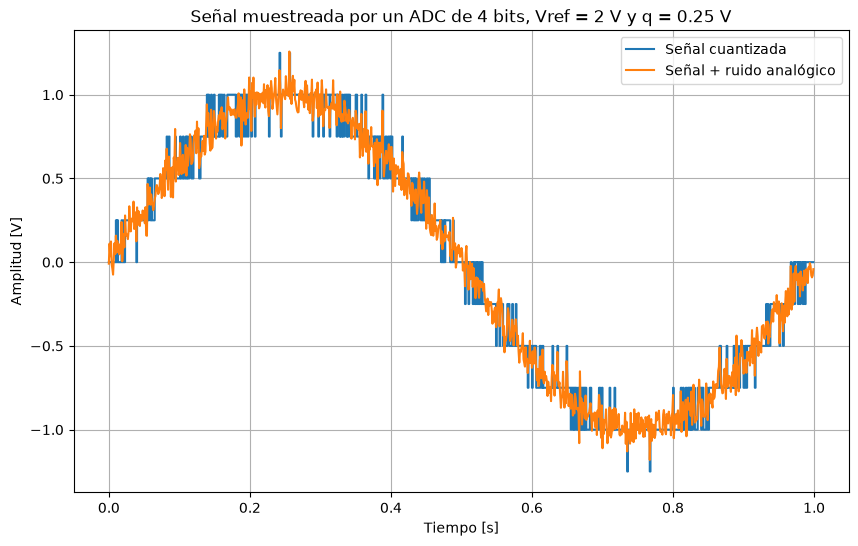

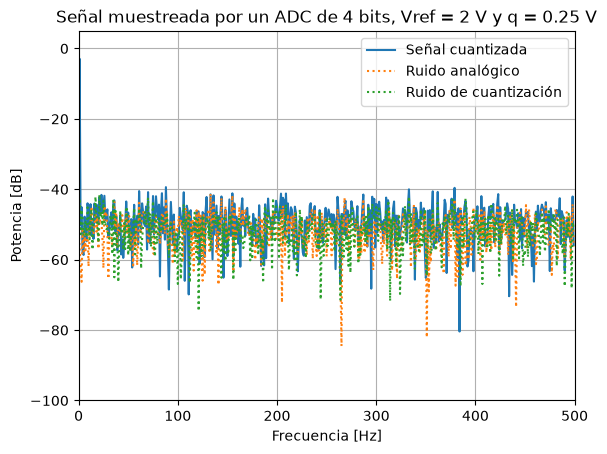

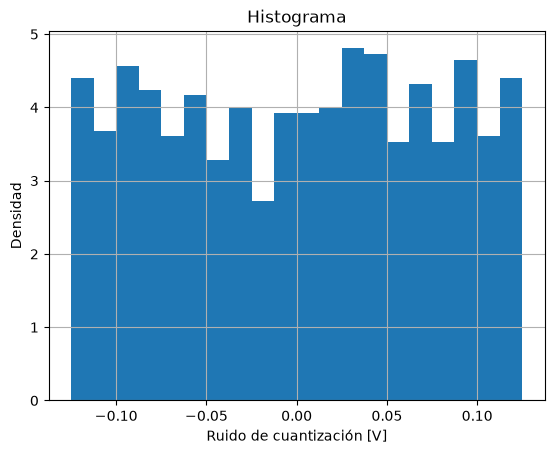

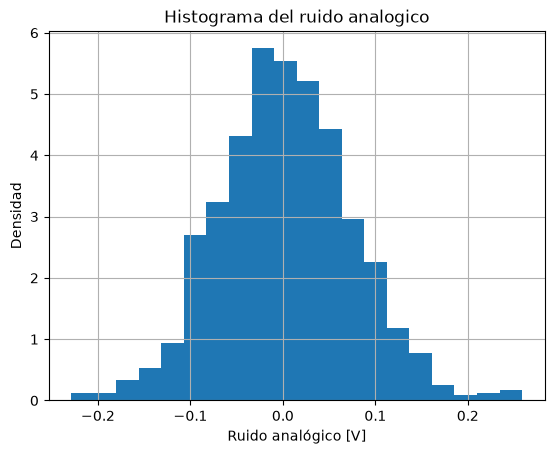

In [37]:
corte = nn // 2
frec_nyquist = np.fft.fftfreq(nn, 1/fs)[:corte]

# FFT de la señal combinada
fft_total = (1/nn)*np.fft.fft(xx_ruidosa)[:corte] #fft normalizada
modulo_dB = 10 * np.log10(2*(np.abs(fft_total))**2) #20 * np.log10(np.abs(fft_total)) #cuando tenemos el modulo ponemos 205
fase = np.angle(fft_total)

#%%nq es incorrelado. Verificacion:

autocorr_nq = np.correlate(nq, nq, mode='full')/nn#matematicamente realiza el producto escalar para cada desplazamiento
#Si K=0, el valor equivale a 1/N, que es la potencia promedio del ruido
#Si K no 0, al dividir por N, la amplitud cae a valores cercanos a 0
lags = np.arange(-nn+1,nn)#representa cuantas muestras desplazamos la señal antes de multilicarla. Se esta comparando asi misma
#%%
#FFT normalizadas por nn para obtener densidad de potencia en db
xx_q_k=(1/nn)*np.fft.fft(xx_q)
ruido_k=(1/nn)*np.fft.fft(ruido)
nq_k=(1/nn)*np.fft.fft(nq)

#potencias
pot_xx_q=2 * (np.abs(xx_q_k[0:(nn//2)])**2)
pot_ruido=2 * (np.abs(ruido_k[0:(nn//2)])**2)
pot_nq=2 * (np.abs(nq_k[0:(nn//2)])**2)

#las paso a db
pot_xx_q_db=10*np.log10(pot_xx_q)
pot_ruido_db=10*np.log10(pot_ruido)
pot_nq_db=10*np.log10(pot_nq)

#%%Graficos
##grafico de la señal origq entraal adc y lo q slae
plt.figure(figsize=(10,6))

plt.step(tt, xx_q, where='post', label='Señal cuantizada')
plt.plot(tt, xx_ruidosa, label='Señal + ruido analógico')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.legend()
plt.show()

#157,158 y 159 en un mismo grafico
plt.figure()

plt.plot(bins, pot_xx_q_db, label='Señal cuantizada')
plt.plot(bins, pot_ruido_db, ':', label='Ruido analógico')
plt.plot(bins, pot_nq_db, ':', label='Ruido de cuantización')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlim(0, 500)
plt.ylim(-100, 5)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid()
plt.legend()
plt.show()

#histograma
plt.figure()
plt.title('Histograma')
plt.hist(nq, bins=20, density=True)
plt.xlabel('Ruido de cuantización [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

plt.figure()
plt.title('Histograma del ruido analogico')
plt.hist(ruido, bins=20, density=True)
plt.xlabel('Ruido analógico [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

Seguimos con los demas experimentos que fue ver que sucedia cuando variabamos B=(4, 8 y 16), con K=(1/10, 1, 10). 

### B=4bits y K=1/10
En este momento predomina el ruido de cuantizacion. La curva de cuantizacion sube y se ubica por encima de la curva del ruido analogico. El piso del ruido total queda dominado casi por completo por nq. 

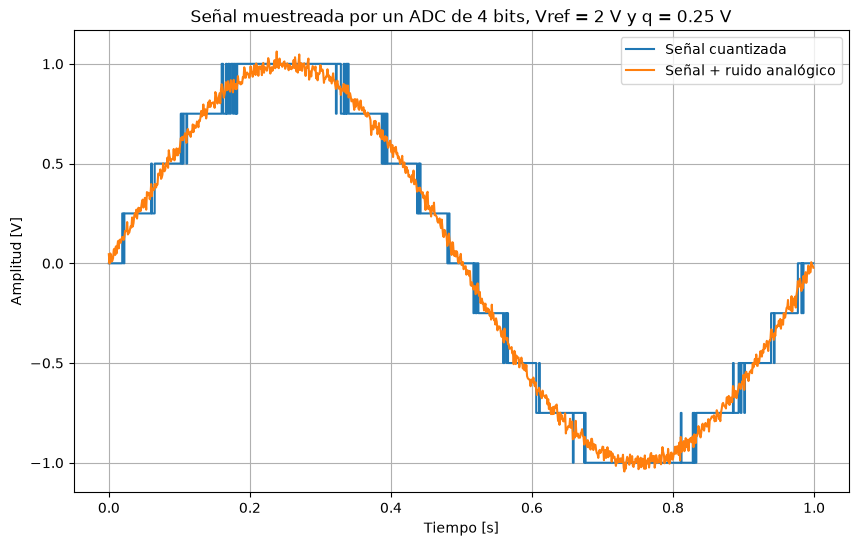

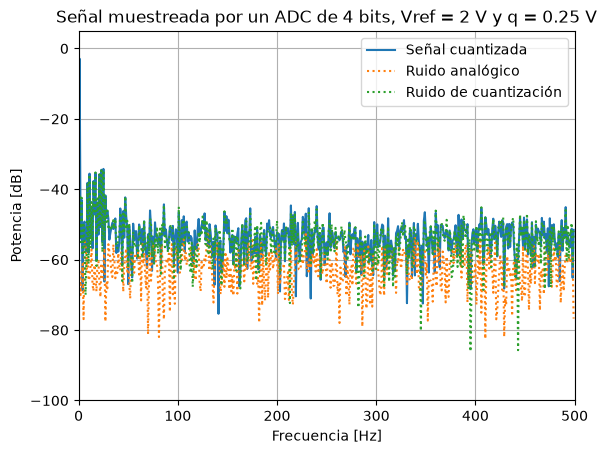

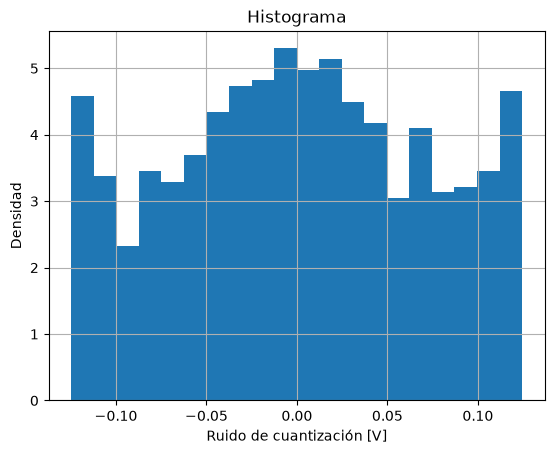

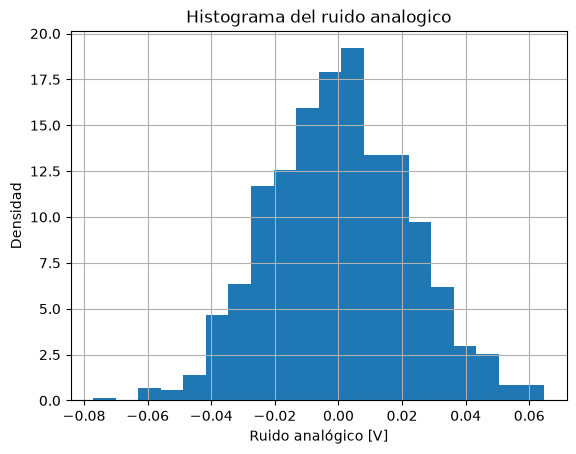

In [38]:
B = 4
kn = 1/10

qq = (2 * Vref) / (2**B)
Pq = (qq**2) / 12
Pn = kn * Pq

ruido = np.random.normal(ur, np.sqrt(Pn), nn)
xx_ruidosa = xx + ruido

xx_q = np.round(xx_ruidosa / qq) * qq
nq = xx_q - xx_ruidosa

corte = nn // 2
frec_nyquist = np.fft.fftfreq(nn, 1/fs)[:corte]

# FFT de la señal combinada
fft_total = (1/nn)*np.fft.fft(xx_ruidosa)[:corte] #fft normalizada
modulo_dB = 10 * np.log10(2*(np.abs(fft_total))**2) #20 * np.log10(np.abs(fft_total)) #cuando tenemos el modulo ponemos 205
fase = np.angle(fft_total)

#%%nq es incorrelado. Verificacion:

autocorr_nq = np.correlate(nq, nq, mode='full')/nn#matematicamente realiza el producto escalar para cada desplazamiento
#Si K=0, el valor equivale a 1/N, que es la potencia promedio del ruido
#Si K no 0, al dividir por N, la amplitud cae a valores cercanos a 0
lags = np.arange(-nn+1,nn)#representa cuantas muestras desplazamos la señal antes de multilicarla. Se esta comparando asi misma
#%%
#FFT normalizadas por nn para obtener densidad de potencia en db
xx_q_k=(1/nn)*np.fft.fft(xx_q)
ruido_k=(1/nn)*np.fft.fft(ruido)
nq_k=(1/nn)*np.fft.fft(nq)

#potencias
pot_xx_q=2 * (np.abs(xx_q_k[0:(nn//2)])**2)
pot_ruido=2 * (np.abs(ruido_k[0:(nn//2)])**2)
pot_nq=2 * (np.abs(nq_k[0:(nn//2)])**2)

#las paso a db
pot_xx_q_db=10*np.log10(pot_xx_q)
pot_ruido_db=10*np.log10(pot_ruido)
pot_nq_db=10*np.log10(pot_nq)

plt.figure(figsize=(10,6))

plt.step(tt, xx_q, where='post', label='Señal cuantizada')
plt.plot(tt, xx_ruidosa, label='Señal + ruido analógico')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.legend()
plt.show()

#157,158 y 159 en un mismo grafico
plt.figure()

plt.plot(bins, pot_xx_q_db, label='Señal cuantizada')
plt.plot(bins, pot_ruido_db, ':', label='Ruido analógico')
plt.plot(bins, pot_nq_db, ':', label='Ruido de cuantización')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlim(0, 500)
plt.ylim(-100, 5)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid()
plt.legend()
plt.show()

#histograma
plt.figure()
plt.title('Histograma')
plt.hist(nq, bins=20, density=True)
plt.xlabel('Ruido de cuantización [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

plt.figure()
plt.title('Histograma del ruido analogico')
plt.hist(ruido, bins=20, density=True)
plt.xlabel('Ruido analógico [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

### B=4bits y K=10
En cambio, en este momento predomina el ruido analogico. En donde, la curva del ruido analogico sube, mientras que la curva de cuantizacion queda en el fondo del grafico. 

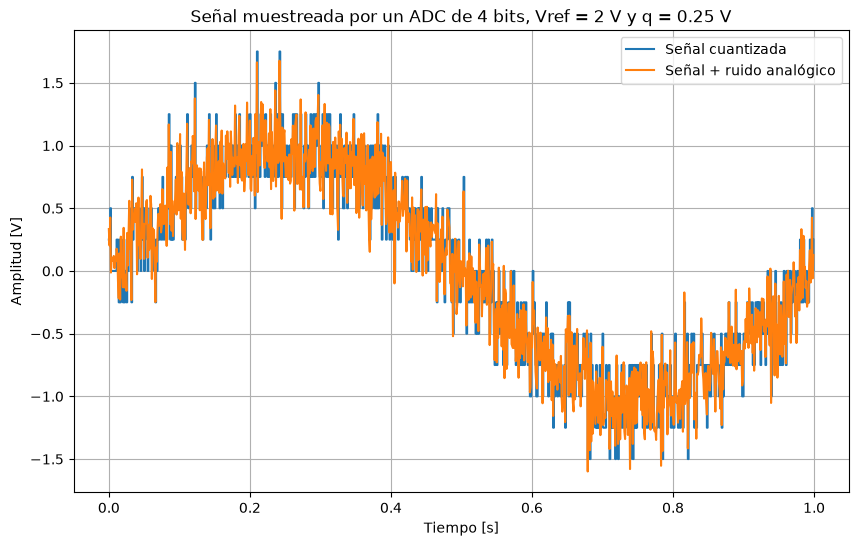

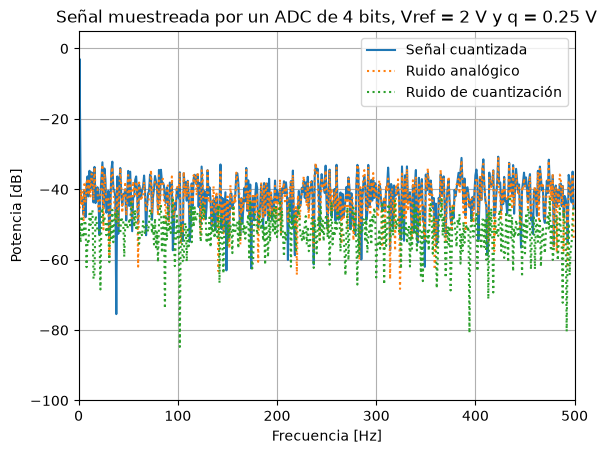

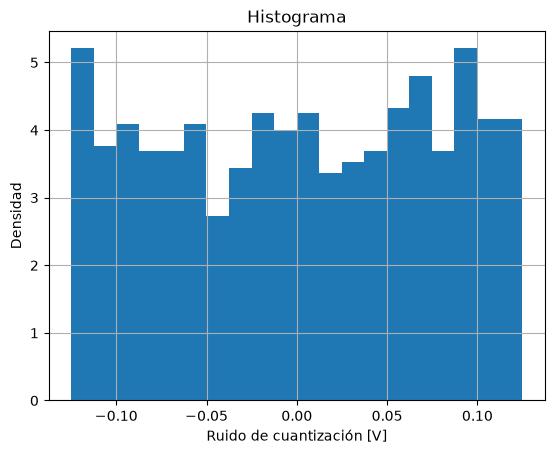

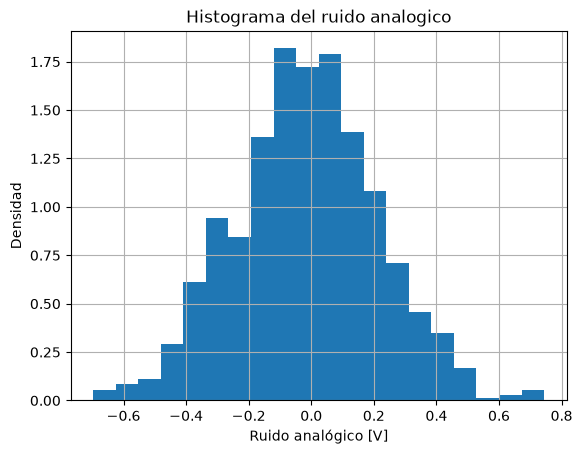

In [39]:
B = 4
kn = 10

qq = (2 * Vref) / (2**B)
Pq = (qq**2) / 12
Pn = kn * Pq

ruido = np.random.normal(ur, np.sqrt(Pn), nn)
xx_ruidosa = xx + ruido

xx_q = np.round(xx_ruidosa / qq) * qq
nq = xx_q - xx_ruidosa

corte = nn // 2
frec_nyquist = np.fft.fftfreq(nn, 1/fs)[:corte]

# FFT de la señal combinada
fft_total = (1/nn)*np.fft.fft(xx_ruidosa)[:corte] #fft normalizada
modulo_dB = 10 * np.log10(2*(np.abs(fft_total))**2) #20 * np.log10(np.abs(fft_total)) #cuando tenemos el modulo ponemos 205
fase = np.angle(fft_total)

#%%nq es incorrelado. Verificacion:

autocorr_nq = np.correlate(nq, nq, mode='full')/nn#matematicamente realiza el producto escalar para cada desplazamiento
#Si K=0, el valor equivale a 1/N, que es la potencia promedio del ruido
#Si K no 0, al dividir por N, la amplitud cae a valores cercanos a 0
lags = np.arange(-nn+1,nn)#representa cuantas muestras desplazamos la señal antes de multilicarla. Se esta comparando asi misma
#%%
#FFT normalizadas por nn para obtener densidad de potencia en db
xx_q_k=(1/nn)*np.fft.fft(xx_q)
ruido_k=(1/nn)*np.fft.fft(ruido)
nq_k=(1/nn)*np.fft.fft(nq)

#potencias
pot_xx_q=2 * (np.abs(xx_q_k[0:(nn//2)])**2)
pot_ruido=2 * (np.abs(ruido_k[0:(nn//2)])**2)
pot_nq=2 * (np.abs(nq_k[0:(nn//2)])**2)

#las paso a db
pot_xx_q_db=10*np.log10(pot_xx_q)
pot_ruido_db=10*np.log10(pot_ruido)
pot_nq_db=10*np.log10(pot_nq)

plt.figure(figsize=(10,6))

plt.step(tt, xx_q, where='post', label='Señal cuantizada')
plt.plot(tt, xx_ruidosa, label='Señal + ruido analógico')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.legend()
plt.show()

#157,158 y 159 en un mismo grafico
plt.figure()

plt.plot(bins, pot_xx_q_db, label='Señal cuantizada')
plt.plot(bins, pot_ruido_db, ':', label='Ruido analógico')
plt.plot(bins, pot_nq_db, ':', label='Ruido de cuantización')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlim(0, 500)
plt.ylim(-100, 5)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid()
plt.legend()
plt.show()

#histograma
plt.figure()
plt.title('Histograma')
plt.hist(nq, bins=20, density=True)
plt.xlabel('Ruido de cuantización [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

plt.figure()
plt.title('Histograma del ruido analogico')
plt.hist(ruido, bins=20, density=True)
plt.xlabel('Ruido analógico [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

A continuacion veremos como al aumentar B, el qq=(2*Vref)//(2**B) se reduce exponencialmente.

### B=8 y K=1

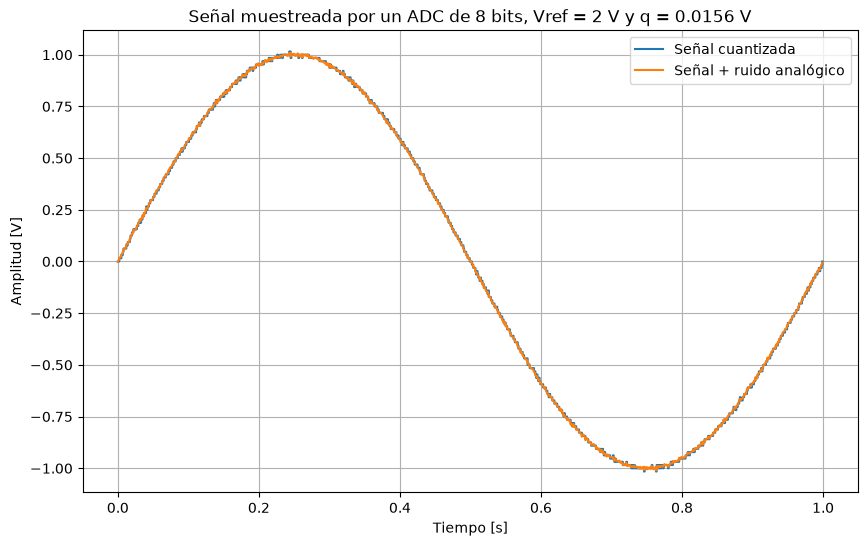

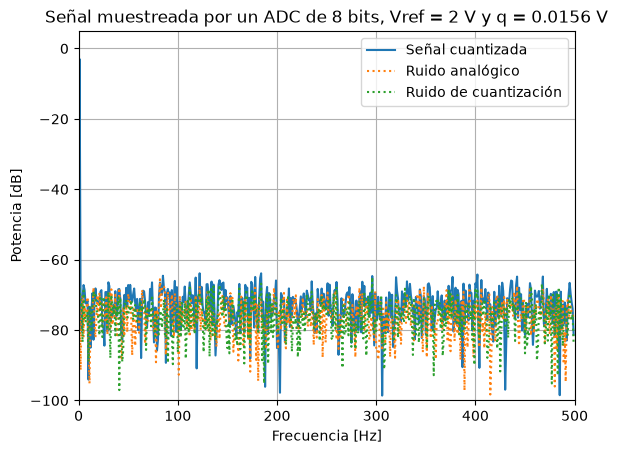

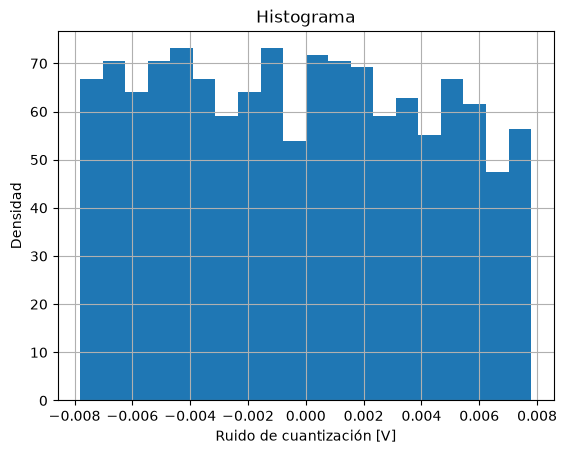

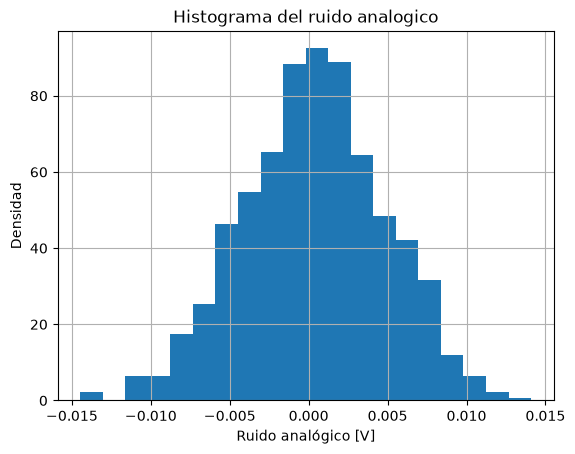

In [40]:
B = 8
kn = 1

qq = (2 * Vref) / (2**B)
Pq = (qq**2) / 12
Pn = kn * Pq

ruido = np.random.normal(ur, np.sqrt(Pn), nn)
xx_ruidosa = xx + ruido

xx_q = np.round(xx_ruidosa / qq) * qq
nq = xx_q - xx_ruidosa

corte = nn // 2
frec_nyquist = np.fft.fftfreq(nn, 1/fs)[:corte]

# FFT de la señal combinada
fft_total = (1/nn)*np.fft.fft(xx_ruidosa)[:corte] #fft normalizada
modulo_dB = 10 * np.log10(2*(np.abs(fft_total))**2) #20 * np.log10(np.abs(fft_total)) #cuando tenemos el modulo ponemos 205
fase = np.angle(fft_total)

#%%nq es incorrelado. Verificacion:

autocorr_nq = np.correlate(nq, nq, mode='full')/nn#matematicamente realiza el producto escalar para cada desplazamiento
#Si K=0, el valor equivale a 1/N, que es la potencia promedio del ruido
#Si K no 0, al dividir por N, la amplitud cae a valores cercanos a 0
lags = np.arange(-nn+1,nn)#representa cuantas muestras desplazamos la señal antes de multilicarla. Se esta comparando asi misma
#%%
#FFT normalizadas por nn para obtener densidad de potencia en db
xx_q_k=(1/nn)*np.fft.fft(xx_q)
ruido_k=(1/nn)*np.fft.fft(ruido)
nq_k=(1/nn)*np.fft.fft(nq)

#potencias
pot_xx_q=2 * (np.abs(xx_q_k[0:(nn//2)])**2)
pot_ruido=2 * (np.abs(ruido_k[0:(nn//2)])**2)
pot_nq=2 * (np.abs(nq_k[0:(nn//2)])**2)

#las paso a db
pot_xx_q_db=10*np.log10(pot_xx_q)
pot_ruido_db=10*np.log10(pot_ruido)
pot_nq_db=10*np.log10(pot_nq)

plt.figure(figsize=(10,6))

plt.step(tt, xx_q, where='post', label='Señal cuantizada')
plt.plot(tt, xx_ruidosa, label='Señal + ruido analógico')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.legend()
plt.show()

#157,158 y 159 en un mismo grafico
plt.figure()

plt.plot(bins, pot_xx_q_db, label='Señal cuantizada')
plt.plot(bins, pot_ruido_db, ':', label='Ruido analógico')
plt.plot(bins, pot_nq_db, ':', label='Ruido de cuantización')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlim(0, 500)
plt.ylim(-100, 5)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid()
plt.legend()
plt.show()

#histograma
plt.figure()
plt.title('Histograma')
plt.hist(nq, bins=20, density=True)
plt.xlabel('Ruido de cuantización [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

plt.figure()
plt.title('Histograma del ruido analogico')
plt.hist(ruido, bins=20, density=True)
plt.xlabel('Ruido analógico [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

### B=8 y K=1/10

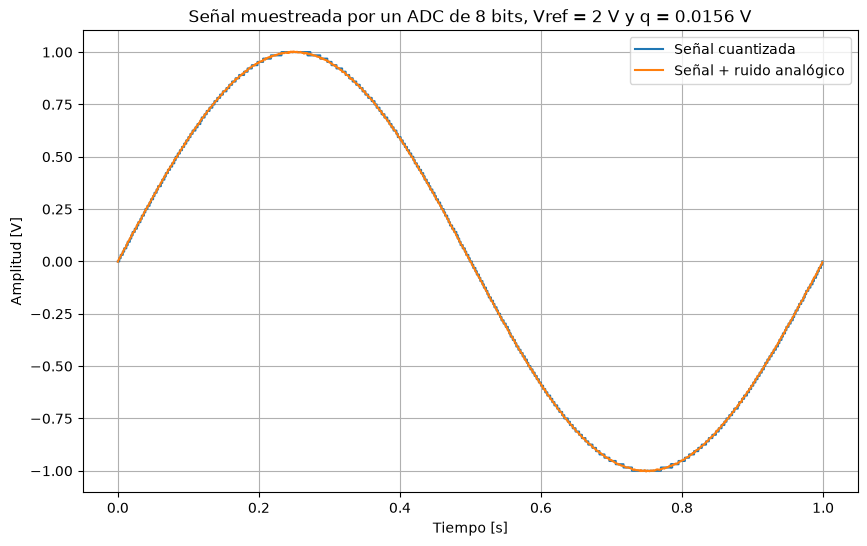

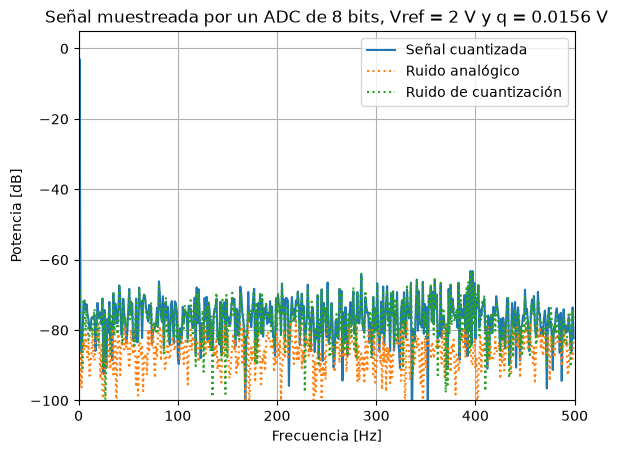

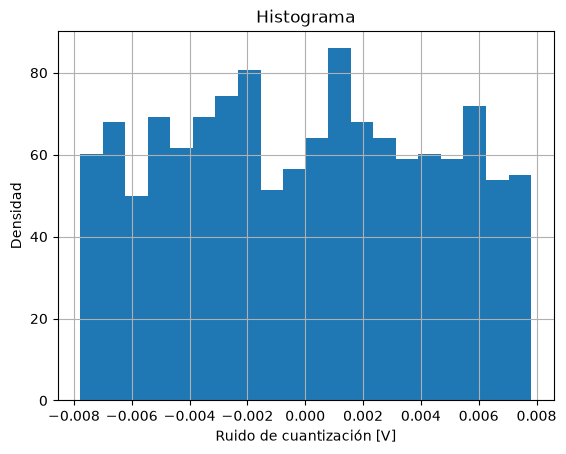

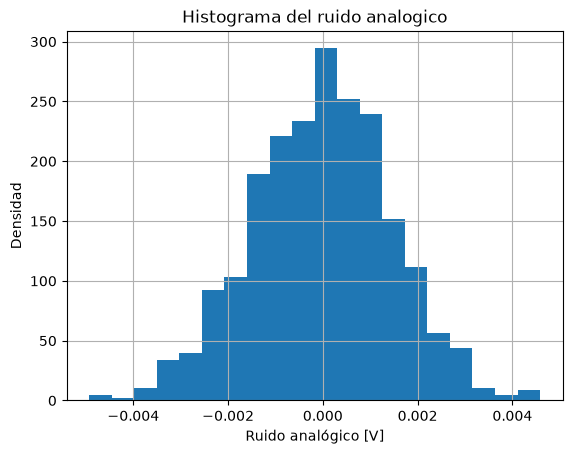

In [43]:
B = 8
kn = 1/10

qq = (2 * Vref) / (2**B)
Pq = (qq**2) / 12
Pn = kn * Pq

ruido = np.random.normal(ur, np.sqrt(Pn), nn)
xx_ruidosa = xx + ruido

xx_q = np.round(xx_ruidosa / qq) * qq
nq = xx_q - xx_ruidosa

corte = nn // 2
frec_nyquist = np.fft.fftfreq(nn, 1/fs)[:corte]

# FFT de la señal combinada
fft_total = (1/nn)*np.fft.fft(xx_ruidosa)[:corte] #fft normalizada
modulo_dB = 10 * np.log10(2*(np.abs(fft_total))**2) #20 * np.log10(np.abs(fft_total)) #cuando tenemos el modulo ponemos 205
fase = np.angle(fft_total)

#%%nq es incorrelado. Verificacion:

autocorr_nq = np.correlate(nq, nq, mode='full')/nn#matematicamente realiza el producto escalar para cada desplazamiento
#Si K=0, el valor equivale a 1/N, que es la potencia promedio del ruido
#Si K no 0, al dividir por N, la amplitud cae a valores cercanos a 0
lags = np.arange(-nn+1,nn)#representa cuantas muestras desplazamos la señal antes de multilicarla. Se esta comparando asi misma
#%%
#FFT normalizadas por nn para obtener densidad de potencia en db
xx_q_k=(1/nn)*np.fft.fft(xx_q)
ruido_k=(1/nn)*np.fft.fft(ruido)
nq_k=(1/nn)*np.fft.fft(nq)

#potencias
pot_xx_q=2 * (np.abs(xx_q_k[0:(nn//2)])**2)
pot_ruido=2 * (np.abs(ruido_k[0:(nn//2)])**2)
pot_nq=2 * (np.abs(nq_k[0:(nn//2)])**2)

#las paso a db
pot_xx_q_db=10*np.log10(pot_xx_q)
pot_ruido_db=10*np.log10(pot_ruido)
pot_nq_db=10*np.log10(pot_nq)

plt.figure(figsize=(10,6))

plt.step(tt, xx_q, where='post', label='Señal cuantizada')
plt.plot(tt, xx_ruidosa, label='Señal + ruido analógico')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.legend()
plt.show()

#157,158 y 159 en un mismo grafico
plt.figure()

plt.plot(bins, pot_xx_q_db, label='Señal cuantizada')
plt.plot(bins, pot_ruido_db, ':', label='Ruido analógico')
plt.plot(bins, pot_nq_db, ':', label='Ruido de cuantización')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlim(0, 500)
plt.ylim(-100, 5)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid()
plt.legend()
plt.show()

#histograma
plt.figure()
plt.title('Histograma')
plt.hist(nq, bins=20, density=True)
plt.xlabel('Ruido de cuantización [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

plt.figure()
plt.title('Histograma del ruido analogico')
plt.hist(ruido, bins=20, density=True)
plt.xlabel('Ruido analógico [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

### B=8 y K=10

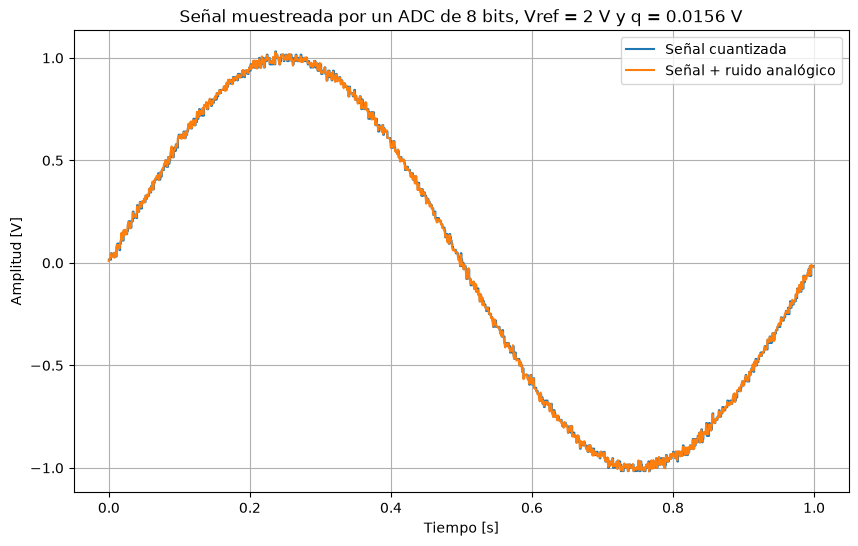

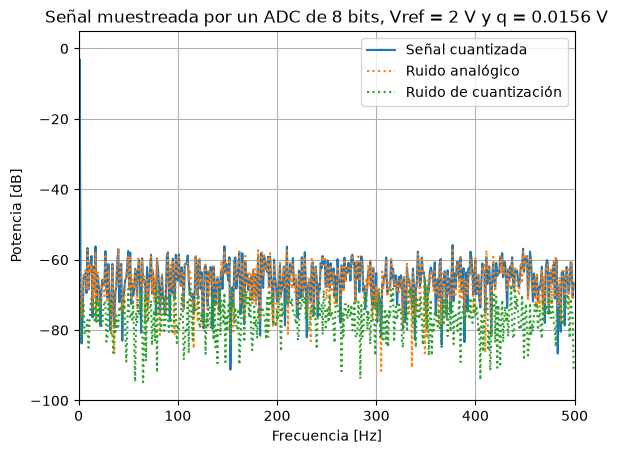

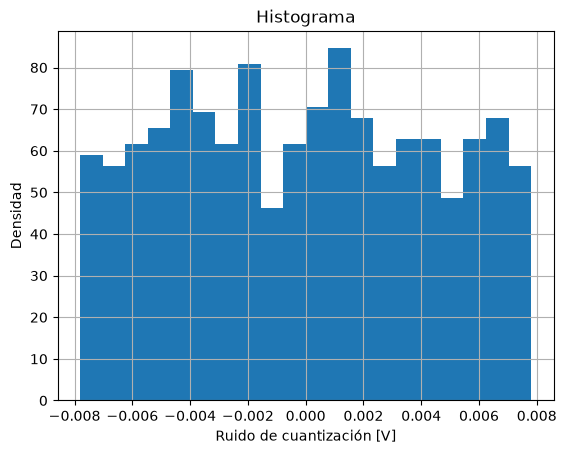

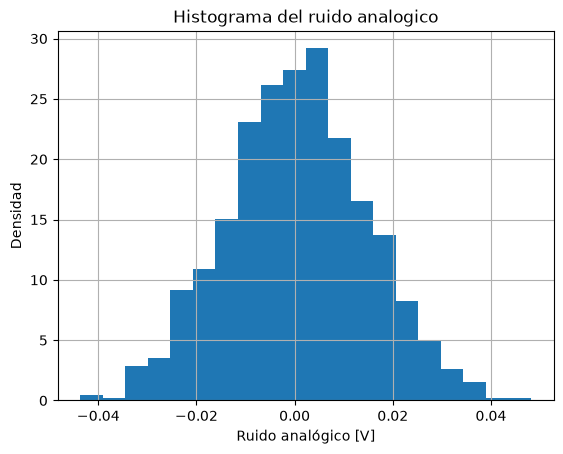

In [44]:
B = 8
kn = 10

qq = (2 * Vref) / (2**B)
Pq = (qq**2) / 12
Pn = kn * Pq

ruido = np.random.normal(ur, np.sqrt(Pn), nn)
xx_ruidosa = xx + ruido

xx_q = np.round(xx_ruidosa / qq) * qq
nq = xx_q - xx_ruidosa

corte = nn // 2
frec_nyquist = np.fft.fftfreq(nn, 1/fs)[:corte]

# FFT de la señal combinada
fft_total = (1/nn)*np.fft.fft(xx_ruidosa)[:corte] #fft normalizada
modulo_dB = 10 * np.log10(2*(np.abs(fft_total))**2) #20 * np.log10(np.abs(fft_total)) #cuando tenemos el modulo ponemos 205
fase = np.angle(fft_total)

#%%nq es incorrelado. Verificacion:

autocorr_nq = np.correlate(nq, nq, mode='full')/nn#matematicamente realiza el producto escalar para cada desplazamiento
#Si K=0, el valor equivale a 1/N, que es la potencia promedio del ruido
#Si K no 0, al dividir por N, la amplitud cae a valores cercanos a 0
lags = np.arange(-nn+1,nn)#representa cuantas muestras desplazamos la señal antes de multilicarla. Se esta comparando asi misma
#%%
#FFT normalizadas por nn para obtener densidad de potencia en db
xx_q_k=(1/nn)*np.fft.fft(xx_q)
ruido_k=(1/nn)*np.fft.fft(ruido)
nq_k=(1/nn)*np.fft.fft(nq)

#potencias
pot_xx_q=2 * (np.abs(xx_q_k[0:(nn//2)])**2)
pot_ruido=2 * (np.abs(ruido_k[0:(nn//2)])**2)
pot_nq=2 * (np.abs(nq_k[0:(nn//2)])**2)

#las paso a db
pot_xx_q_db=10*np.log10(pot_xx_q)
pot_ruido_db=10*np.log10(pot_ruido)
pot_nq_db=10*np.log10(pot_nq)

plt.figure(figsize=(10,6))

plt.step(tt, xx_q, where='post', label='Señal cuantizada')
plt.plot(tt, xx_ruidosa, label='Señal + ruido analógico')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.legend()
plt.show()

#157,158 y 159 en un mismo grafico
plt.figure()

plt.plot(bins, pot_xx_q_db, label='Señal cuantizada')
plt.plot(bins, pot_ruido_db, ':', label='Ruido analógico')
plt.plot(bins, pot_nq_db, ':', label='Ruido de cuantización')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlim(0, 500)
plt.ylim(-100, 5)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid()
plt.legend()
plt.show()

#histograma
plt.figure()
plt.title('Histograma')
plt.hist(nq, bins=20, density=True)
plt.xlabel('Ruido de cuantización [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

plt.figure()
plt.title('Histograma del ruido analogico')
plt.hist(ruido, bins=20, density=True)
plt.xlabel('Ruido analógico [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

Y como ultimo veremos que pasa con B=16

### B=16 y K=1

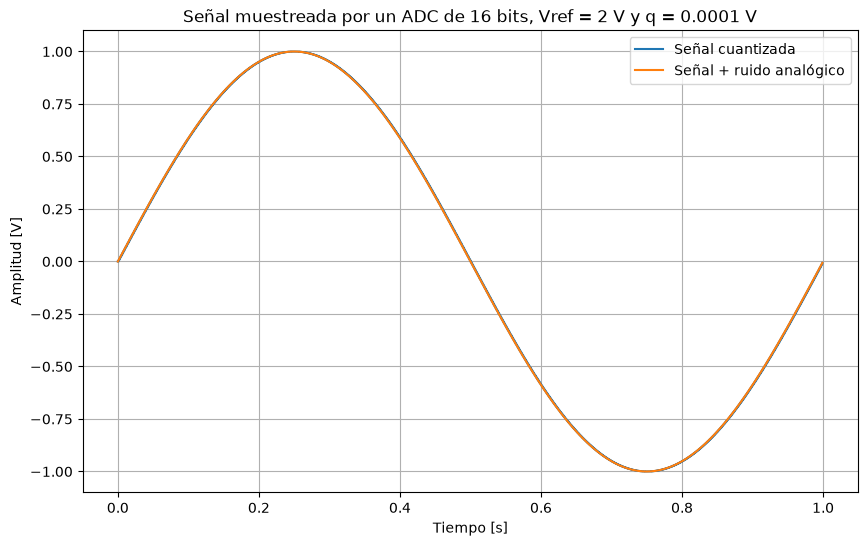

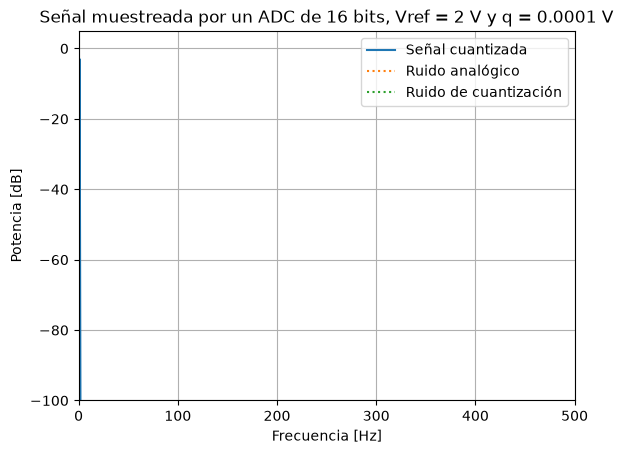

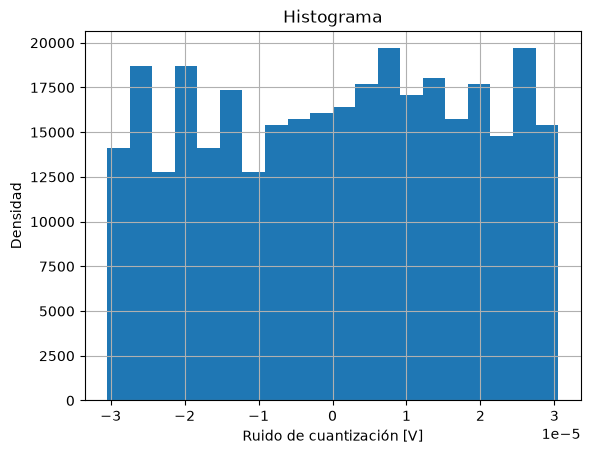

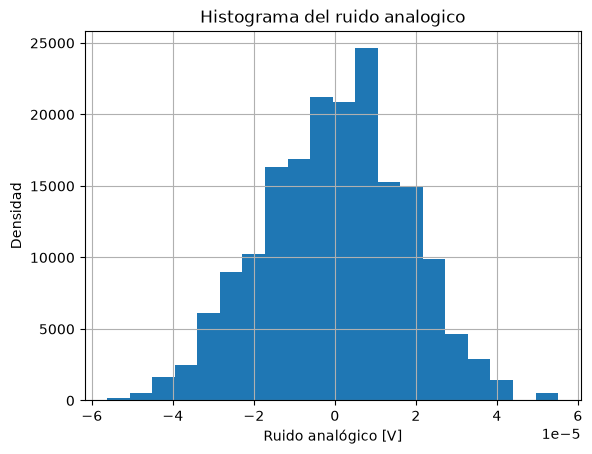

In [46]:
B = 16
kn = 1

qq = (2 * Vref) / (2**B)
Pq = (qq**2) / 12
Pn = kn * Pq

ruido = np.random.normal(ur, np.sqrt(Pn), nn)
xx_ruidosa = xx + ruido

xx_q = np.round(xx_ruidosa / qq) * qq
nq = xx_q - xx_ruidosa

corte = nn // 2
frec_nyquist = np.fft.fftfreq(nn, 1/fs)[:corte]

# FFT de la señal combinada
fft_total = (1/nn)*np.fft.fft(xx_ruidosa)[:corte] #fft normalizada
modulo_dB = 10 * np.log10(2*(np.abs(fft_total))**2) #20 * np.log10(np.abs(fft_total)) #cuando tenemos el modulo ponemos 205
fase = np.angle(fft_total)

#%%nq es incorrelado. Verificacion:

autocorr_nq = np.correlate(nq, nq, mode='full')/nn#matematicamente realiza el producto escalar para cada desplazamiento
#Si K=0, el valor equivale a 1/N, que es la potencia promedio del ruido
#Si K no 0, al dividir por N, la amplitud cae a valores cercanos a 0
lags = np.arange(-nn+1,nn)#representa cuantas muestras desplazamos la señal antes de multilicarla. Se esta comparando asi misma
#%%
#FFT normalizadas por nn para obtener densidad de potencia en db
xx_q_k=(1/nn)*np.fft.fft(xx_q)
ruido_k=(1/nn)*np.fft.fft(ruido)
nq_k=(1/nn)*np.fft.fft(nq)

#potencias
pot_xx_q=2 * (np.abs(xx_q_k[0:(nn//2)])**2)
pot_ruido=2 * (np.abs(ruido_k[0:(nn//2)])**2)
pot_nq=2 * (np.abs(nq_k[0:(nn//2)])**2)

#las paso a db
pot_xx_q_db=10*np.log10(pot_xx_q)
pot_ruido_db=10*np.log10(pot_ruido)
pot_nq_db=10*np.log10(pot_nq)

plt.figure(figsize=(10,6))

plt.step(tt, xx_q, where='post', label='Señal cuantizada')
plt.plot(tt, xx_ruidosa, label='Señal + ruido analógico')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.legend()
plt.show()

#157,158 y 159 en un mismo grafico
plt.figure()

plt.plot(bins, pot_xx_q_db, label='Señal cuantizada')
plt.plot(bins, pot_ruido_db, ':', label='Ruido analógico')
plt.plot(bins, pot_nq_db, ':', label='Ruido de cuantización')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlim(0, 500)
plt.ylim(-100, 5)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid()
plt.legend()
plt.show()

#histograma
plt.figure()
plt.title('Histograma')
plt.hist(nq, bins=20, density=True)
plt.xlabel('Ruido de cuantización [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

plt.figure()
plt.title('Histograma del ruido analogico')
plt.hist(ruido, bins=20, density=True)
plt.xlabel('Ruido analógico [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

### B=16 y K=1/10

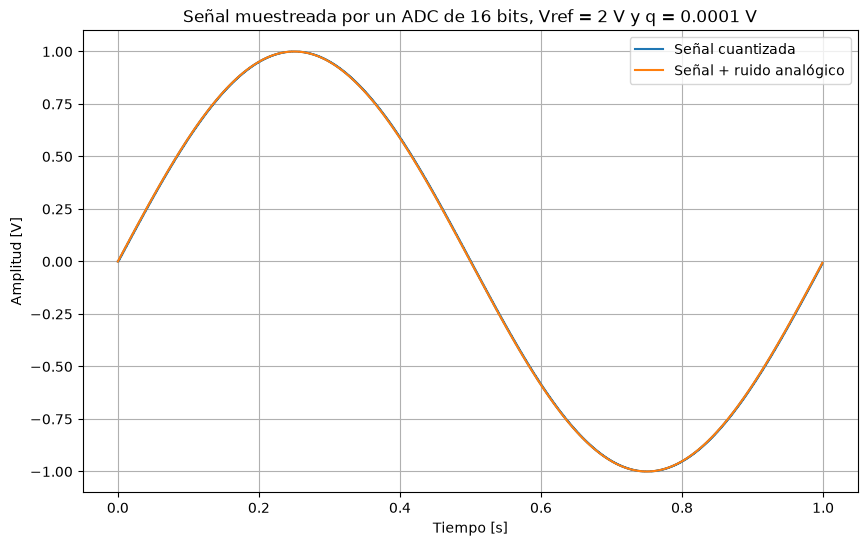

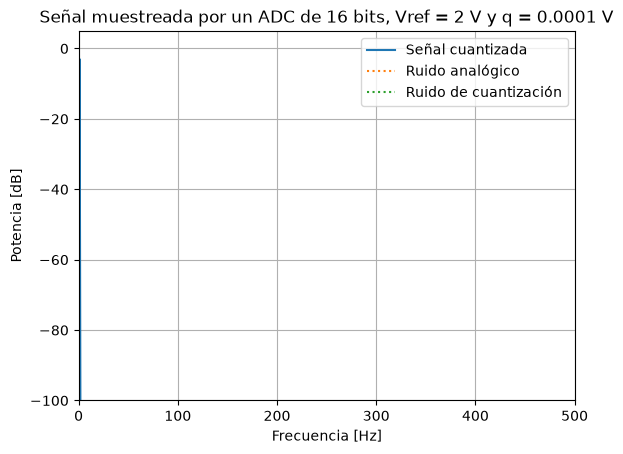

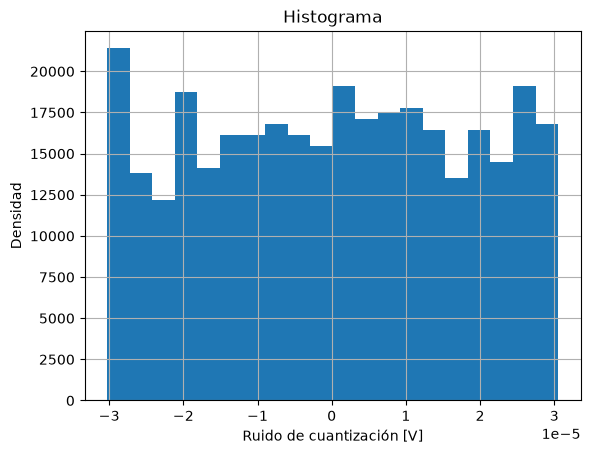

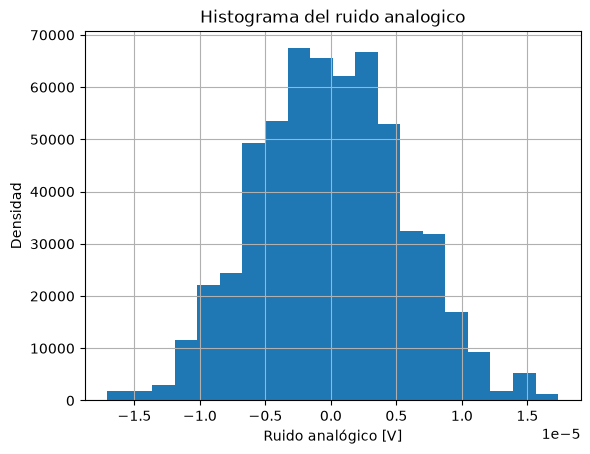

In [47]:
B = 16
kn = 1/10

qq = (2 * Vref) / (2**B)
Pq = (qq**2) / 12
Pn = kn * Pq

ruido = np.random.normal(ur, np.sqrt(Pn), nn)
xx_ruidosa = xx + ruido

xx_q = np.round(xx_ruidosa / qq) * qq
nq = xx_q - xx_ruidosa

corte = nn // 2
frec_nyquist = np.fft.fftfreq(nn, 1/fs)[:corte]

# FFT de la señal combinada
fft_total = (1/nn)*np.fft.fft(xx_ruidosa)[:corte] #fft normalizada
modulo_dB = 10 * np.log10(2*(np.abs(fft_total))**2) #20 * np.log10(np.abs(fft_total)) #cuando tenemos el modulo ponemos 205
fase = np.angle(fft_total)

#%%nq es incorrelado. Verificacion:

autocorr_nq = np.correlate(nq, nq, mode='full')/nn#matematicamente realiza el producto escalar para cada desplazamiento
#Si K=0, el valor equivale a 1/N, que es la potencia promedio del ruido
#Si K no 0, al dividir por N, la amplitud cae a valores cercanos a 0
lags = np.arange(-nn+1,nn)#representa cuantas muestras desplazamos la señal antes de multilicarla. Se esta comparando asi misma
#%%
#FFT normalizadas por nn para obtener densidad de potencia en db
xx_q_k=(1/nn)*np.fft.fft(xx_q)
ruido_k=(1/nn)*np.fft.fft(ruido)
nq_k=(1/nn)*np.fft.fft(nq)

#potencias
pot_xx_q=2 * (np.abs(xx_q_k[0:(nn//2)])**2)
pot_ruido=2 * (np.abs(ruido_k[0:(nn//2)])**2)
pot_nq=2 * (np.abs(nq_k[0:(nn//2)])**2)

#las paso a db
pot_xx_q_db=10*np.log10(pot_xx_q)
pot_ruido_db=10*np.log10(pot_ruido)
pot_nq_db=10*np.log10(pot_nq)

plt.figure(figsize=(10,6))

plt.step(tt, xx_q, where='post', label='Señal cuantizada')
plt.plot(tt, xx_ruidosa, label='Señal + ruido analógico')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.legend()
plt.show()

#157,158 y 159 en un mismo grafico
plt.figure()

plt.plot(bins, pot_xx_q_db, label='Señal cuantizada')
plt.plot(bins, pot_ruido_db, ':', label='Ruido analógico')
plt.plot(bins, pot_nq_db, ':', label='Ruido de cuantización')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlim(0, 500)
plt.ylim(-100, 5)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid()
plt.legend()
plt.show()

#histograma
plt.figure()
plt.title('Histograma')
plt.hist(nq, bins=20, density=True)
plt.xlabel('Ruido de cuantización [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

plt.figure()
plt.title('Histograma del ruido analogico')
plt.hist(ruido, bins=20, density=True)
plt.xlabel('Ruido analógico [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

### B=16 y K=10

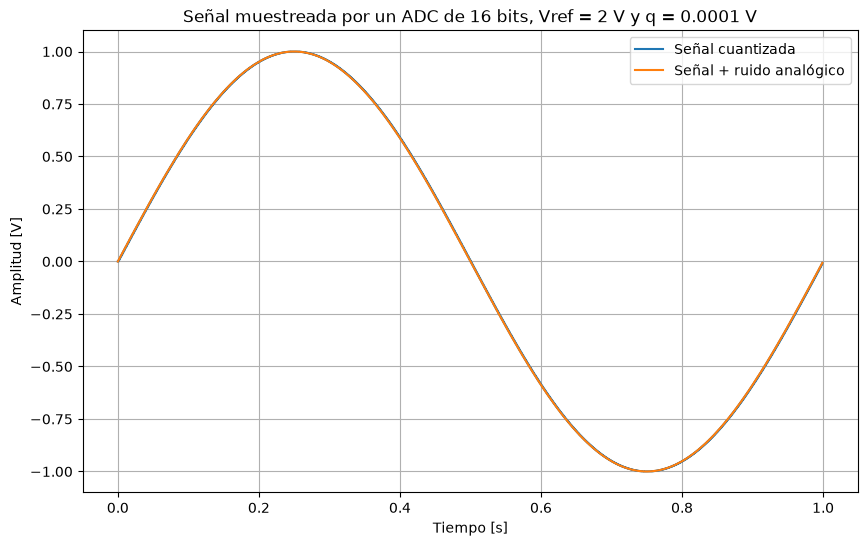

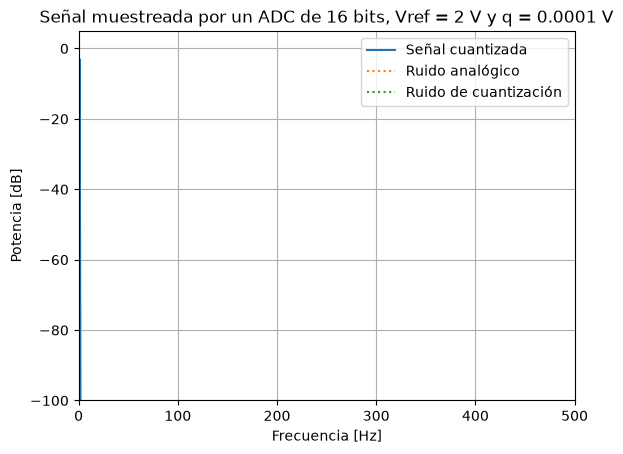

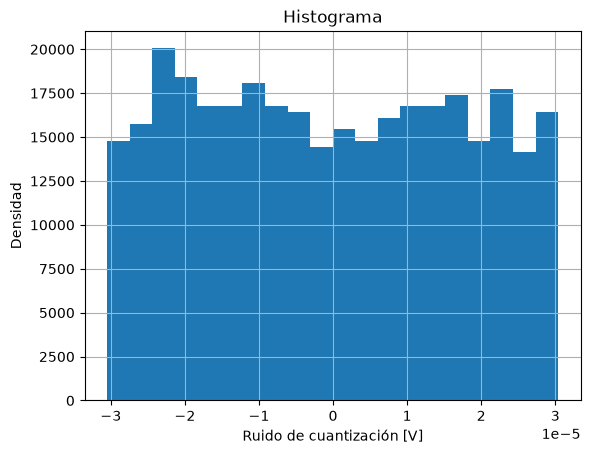

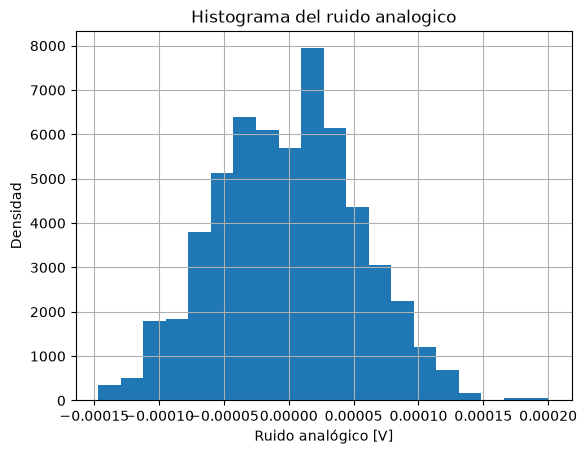

In [49]:
B = 16
kn = 10

qq = (2 * Vref) / (2**B)
Pq = (qq**2) / 12
Pn = kn * Pq

ruido = np.random.normal(ur, np.sqrt(Pn), nn)
xx_ruidosa = xx + ruido

xx_q = np.round(xx_ruidosa / qq) * qq
nq = xx_q - xx_ruidosa

corte = nn // 2
frec_nyquist = np.fft.fftfreq(nn, 1/fs)[:corte]

# FFT de la señal combinada
fft_total = (1/nn)*np.fft.fft(xx_ruidosa)[:corte] #fft normalizada
modulo_dB = 10 * np.log10(2*(np.abs(fft_total))**2) #20 * np.log10(np.abs(fft_total)) #cuando tenemos el modulo ponemos 205
fase = np.angle(fft_total)

#%%nq es incorrelado. Verificacion:

autocorr_nq = np.correlate(nq, nq, mode='full')/nn#matematicamente realiza el producto escalar para cada desplazamiento
#Si K=0, el valor equivale a 1/N, que es la potencia promedio del ruido
#Si K no 0, al dividir por N, la amplitud cae a valores cercanos a 0
lags = np.arange(-nn+1,nn)#representa cuantas muestras desplazamos la señal antes de multilicarla. Se esta comparando asi misma
#%%
#FFT normalizadas por nn para obtener densidad de potencia en db
xx_q_k=(1/nn)*np.fft.fft(xx_q)
ruido_k=(1/nn)*np.fft.fft(ruido)
nq_k=(1/nn)*np.fft.fft(nq)

#potencias
pot_xx_q=2 * (np.abs(xx_q_k[0:(nn//2)])**2)
pot_ruido=2 * (np.abs(ruido_k[0:(nn//2)])**2)
pot_nq=2 * (np.abs(nq_k[0:(nn//2)])**2)

#las paso a db
pot_xx_q_db=10*np.log10(pot_xx_q)
pot_ruido_db=10*np.log10(pot_ruido)
pot_nq_db=10*np.log10(pot_nq)

plt.figure(figsize=(10,6))

plt.step(tt, xx_q, where='post', label='Señal cuantizada')
plt.plot(tt, xx_ruidosa, label='Señal + ruido analógico')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.legend()
plt.show()

#157,158 y 159 en un mismo grafico
plt.figure()

plt.plot(bins, pot_xx_q_db, label='Señal cuantizada')
plt.plot(bins, pot_ruido_db, ':', label='Ruido analógico')
plt.plot(bins, pot_nq_db, ':', label='Ruido de cuantización')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits, Vref = ' + str(Vref) + ' V y q = ' + str(round(qq,4)) + ' V')

plt.xlim(0, 500)
plt.ylim(-100, 5)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid()
plt.legend()
plt.show()

#histograma
plt.figure()
plt.title('Histograma')
plt.hist(nq, bins=20, density=True)
plt.xlabel('Ruido de cuantización [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

plt.figure()
plt.title('Histograma del ruido analogico')
plt.hist(ruido, bins=20, density=True)
plt.xlabel('Ruido analógico [V]')
plt.ylabel('Densidad')
plt.grid()
plt.show()

Al terminar la experimentacion podemos ver como a medida que aumentabamos el numero de bits, B, el paso de cuantizacion qq=(2*Vref)//(2**B) disminuia exponencialmente, haciendo que el Pq=(qq**2)//12 se reduzca. Pudimos observar como para B=16, deberiamos aumentar nuestras muestras para poder bien que es lo que sucedia o ajustar la escala. 
Se observo que para K=1/10 el sistema estaba limitado por el ADC (Pq>Pn), ya que, se encuentra mas procesamiento digital que analogico. Con K=1, estamos en el caso optimo (Pq=Pn); y por ultimo, K=10 donde el rudio analogico predomina (Pq<Pn), por lo que al aumentar la resolucion del convertidor no genera ninguna mejora observable en la señal final. Por eso, es recomendable analizar las k antes que los bits. 